In [58]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import numpy as np

X, y = make_blobs(
    n_samples=200,
    centers=2,
    random_state=15,
    cluster_std=2
)

y = 2*y - 1

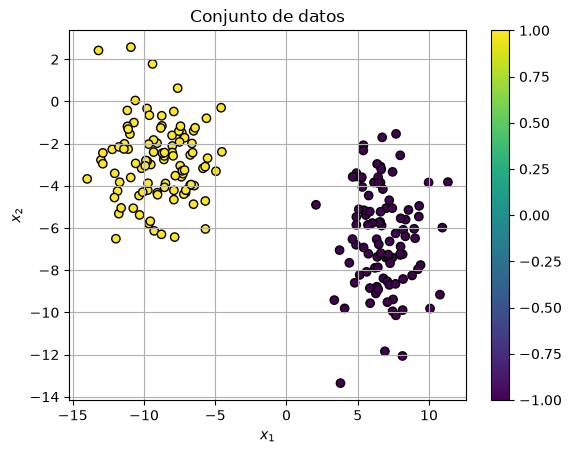

In [59]:
plt.scatter(X[:,0],X[:,1], c=y, cmap='viridis' , edgecolor='k')
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Conjunto de datos")
plt.colorbar()
plt.grid(True)
plt.show()

In [60]:
w=np.array([1,1])
b=0
z=y*(X@w + b )

In [61]:
r=z[z>0]
wr=z[z<0]
print(f"Correctos {len(r)}, incorrectos {len(wr)}")

Correctos 44, incorrectos 156


In [73]:
def hinge(z):
    return np.maximum(0,1-z)
def logloss(z):
    return np.log(1+np.exp(-z))


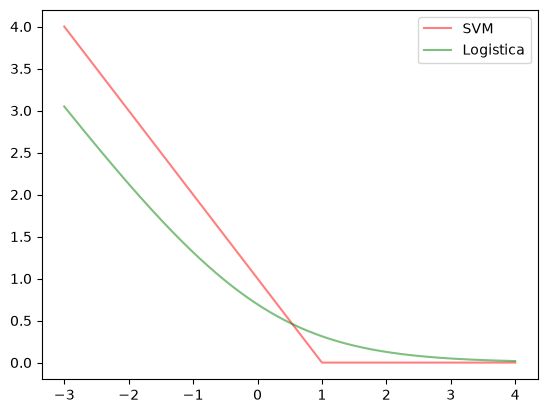

In [75]:
z=np.linspace(-3,4,300)
plt.plot(z,hinge(z),label='SVM', color="r", alpha=0.5)
plt.plot(z,logloss(z), label="Logistica", color='g', alpha=0.5)
plt.legend()
plt.show()


In [ ]:
class LogisticRegresion():
    def __init__(self, epoch=500,lr=0.05, lam=1):
        self.epoch=epoch
        self.lr=lr
        self.lam=lam
    
    def sigmoid(self, z):
        return 1/(1+np.exp(-z))

    def fit(self, x,y):
        m,n=x.shape
        w=np.random.rand(n)
        b=np.random.rand(1)
        for epoch in range(self.epoch):
            z=y*(x@w + b)
            s=self.sigmoid(-z)
            gradw=-(x.T@(y*s)) + 2*self.lam*w
            gradb=-np.sum(y*s)
            w-=self.lr*gradw
            b-=self.lr*gradb
        self.w=w
        self.b=b 

    def predict_proba(self,x):
        z=(x@self.w + self.b)
        return self.sigmoid(z)

    def predict(self,x,threshold):
        probs=self.predict_proba(x)
        return np.where(probs>=threshold, 1,-1)

In [78]:
modelo=LogisticRegresion()

In [79]:
modelo.fit(X,y)

C:\Users\Pablo Duran\AppData\Local\Temp\ipykernel_14200\2401978568.py:8: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-z))


In [82]:
y_pred=modelo.predict(X,0.5)

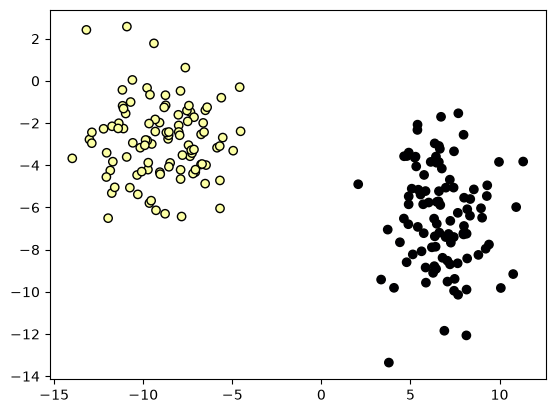

In [87]:
plt.scatter(X[:,0],X[:,1], c=y_pred,cmap='inferno', edgecolor='k')